Task 3

IMDB Dataset of 50K Movie Reviews: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

This dataset contains 50,000 movie reviews labeled as positive or negative. Each example is a piece of natural language text which forms a sequence of words. The order of words in a review is meaningful and contributes to the overall sentiment meaning of the text.

Part 1: Implementing Word Embeddings

In [ ]:
# using genism to load pre-trained GloVe embedding model
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.6 MB/s eta 0:00:00


I used Gensim to download a pre-trained GloVe model trained on the Wikipedia + Gigaword corpus. GloVe (Global Vectors for Word Representation) is a word embedding model that learns vector representations of words based on global word co-occurrence statistics in a large text corpus. The Wikipedia + Gigaword corpus contains billions of tokens from encyclopedic articles and news text, which provides broad vocabulary coverage and semantic relationships between words. Since the model is trained on such a large dataset, it captures general semantic and syntactic relationships. This makes it good for NLP tasks because it provides meaningful word representations without requiring training embeddings from scratch.\
\
**Comparitive discussion** \
GloVe was chosen over other embedding methods because of its balance between computational efficiency and strong semantic representation. Word2Vec, relies on local context window predictions, where GloVe leverages global word co-occurrence statistics from the entire corpus. This would result in more stable and interpretable semantic relationships in embedding space. Compared to FastText, which models subword information and handles out-of-vocabulary words better, GloVe is simpler and faster to load, making it better for interactive computation and visualization tasks. Contextual embeddings like BERT provide dynamic word representations but they are computationally heavier and unnecessary for this task. Since the dataset primarily contains common vocabulary and the focus was on stable semantic similarity rather than contextual nuance, GloVe was an efficient and effective choice. \
Citation: https://nlp.stanford.edu/pubs/glove.pdf

In [ ]:
import gensim.downloader as api
import numpy as np

# loading glove embeddings efficiently

print("Loading GloVe embeddings")
glove = api.load("glove-wiki-gigaword-100")  # 100-dimensional GloVe vectors
print("Loaded GloVe embeddings")

Loading GloVe embeddings
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded GloVe embeddings


In [ ]:
# dynamic user input of two words and output respective embeddings

'''
Takes two user-input words and prints embedding vectors

Parameters:
  word1: first word to look up
  word2: second word to look up
  model: pre-trained embedding model

Returns:
  tuple:
    v1: embedding for word1 or None if not found
    v2: embedding for word1 or None if not found
'''
def get_embeddings(word1, word2, model):
    '''
    Helper function to get word vector from model

    Parameters:
      word: word to retrieve embedding for

    Returns:
      vector:
        embedding vector if word exists in model
        else None
    '''
    def get_vec(word):
        if word in model:
            return model[word]
        else:
            return None

    # get embedding vectors for both words
    v1 = get_vec(word1)
    v2 = get_vec(word2)

    print(f"\nEmbedding for '{word1}':")
    print(v1)

    print(f"\nEmbedding for '{word2}':")
    print(v2)

    return v1, v2

In [ ]:
# handle cases where word is OOV + suggest ways to approximate embedding

'''
out of vocabulary (OOV) words handled by lowercasing,
splitting into subwords, and suggesting alternatives

Parameters:
  word: input word from user
  model: pre-trained embedding model

Returns:
  tuple:
    vector: embedding vector if found else None
    message: explanation of how embedding obtained/failed
'''
def get_embedding_with_oov_handling(word, model):
    # exact match in embedding vocab
    if word in model:
        return model[word], "Exact match found."

    # trying lowercasing word
    word_lower = word.lower()
    if word_lower in model:
        return model[word_lower], "Found by lowercasing."

    # collecting embeddings for subwords that exist in the model
    subwords = [w for w in word_lower.replace("-", " ").split()]
    sub_vecs = [model[w] for w in subwords if w in model]

    # if at least one subword vector, averages
    if len(sub_vecs) > 0:
        return np.mean(sub_vecs, axis=0), "Approximated by averaging subword embeddings."

    # suggest ways to approximate embedding
    return None, "OOV: Try synonyms, lowercasing, or using FastText (subword-based embeddings)."

# example user inputs run
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

# embeddings with oov handling
v1, msg1 = get_embedding_with_oov_handling(word1, glove)
v2, msg2 = get_embedding_with_oov_handling(word2, glove)

print(f"\n{word1}: {msg1}")
print(f"{word2}: {msg2}")

print(f"\nFinal embedding for '{word1}':\n", v1)
print(f"\nFinal embedding for '{word2}':\n", v2)

Enter first word: amazin
Enter second word: wnderful

amazin: Exact match found.
wnderful: OOV: Try synonyms, lowercasing, or using FastText (subword-based embeddings).

Final embedding for 'amazin':
 [-0.62151  -0.094296  0.11537   0.24034  -0.47503  -0.77181   0.53363
 -0.382     0.12412  -0.59697   0.30743   0.18087   0.13067  -0.79039
 -0.55672   0.12617   0.2022    0.53183   0.88417   0.32349   0.30259
 -0.085362 -0.2152   -0.11613   0.24937  -0.22055  -0.17741  -0.10977
  0.066835  0.049672  0.25664  -0.093562 -0.21251  -0.055075 -0.21059
  0.12615  -0.096471 -0.11563  -0.049156 -0.58953   0.57831  -0.25803
  0.078613  0.48026   0.083622  0.16009   0.36008   0.36567   0.72075
  0.88416  -0.21522  -0.12449  -0.20318  -0.75751  -1.0519    0.77949
  1.2061    0.2877   -0.49313  -0.34609  -0.52227   0.35798  -0.15406
 -0.67671   0.0394   -0.10235  -0.047475 -0.71827  -0.40614  -0.47009
 -0.067676  0.078944 -0.72182  -0.1415    0.52343   0.22524  -0.48168
 -0.015386  0.39131  -0.32473

The example output shows that the pre-trained GloVe (glove-wiki-gigaword-100) embeddings were successfully loaded using Gensim. The model returns a 100-dimensional dense vector for in-vocabulary words, as shown for "amazin." The user is able to input words with the dynamic user input and retrieve their embeddings interactively. When a word is not found in the vocabulary, such as "wnderful," the system correctly identifies it as out-of-vocabulary (OOV) and returns None. It also suggests alternative strategies, such as lowercasing, using synonyms, or switching to subword-based embeddings like FastText to approximate representations.

Part 2: Cosine Similarity Computation

In [ ]:
# implement function that computes cosine similarity between two-word embeddings

import numpy as np

'''
Compute cosine similarity between two embedding vectors

Parameters:
  vec1: first embedding vector
  vec2: second embedding vector
  eps: small constant to avoid div by zero

Returns:
  cosine similarity score if both vectors exist
  else None
'''
def cosine_similarity(vec1, vec2, eps=1e-8):
    # if either vector missing, similarity cannot be computed
    if vec1 is None or vec2 is None:
        return None

    # compute dot product between two vectors
    dot_product = np.dot(vec1, vec2)

    # compute magnitudes (L2 norms) of each vector
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    # compute cosine similarity with epsilon to prevent div by zero
    similarity = dot_product / (norm_vec1 * norm_vec2 + eps)

    return similarity

**Explain why cosine similarity is useful in word embedding space** \
Cosine similarity is useful in word embedding space because it measures semantic alignment between word vectors based on direction rather than magnitude, which makes it robust to frequency effects and well-suited for high-dimensional semantic representations. It focuses on whether two words point in the same direction in vector space, which aligns well with how embeddings are trained. Words used in similar contexts end up with vectors pointing in similar directions. Two vectors can have different lengths but still represent similar meanings. Cosine similarity ignores magnitude and only measures orientation. This prevents frequent words from unfairly dominating similarity scores. It works well in high-dimensional spaces and has interpretable similarity scores. Cosine similarity is bounded between -1 and 1, where 1 represents very similar meanings, 0 represents unrelated words, and -1 represents opposite directions in vector space. This makes it easy to interpret and visualize similarity relationships.

In [ ]:
# allow batch processing where users can input multiple word pairs for
# simultaneous similairty computation

'''
Compute cosine similarity for multiple pairs in one batch

Parameters:
  word_pairs: list of words pairs
  model: pre-trained embedding model

Returns:
  dict:
    keys: (word1, word2) tuples
    values: cosine similarity score or None if OOV
'''
def batch_cosine_similarity(word_pairs, model):
    results = {}
    for w1, w2 in word_pairs:
        # get embeddings and OOV message for both words
        v1, msg1 = get_embedding_with_oov_handling(w1, model)
        v2, msg2 = get_embedding_with_oov_handling(w2, model)

        # compute cosine similarity
        sim = cosine_similarity(v1, v2)

        # storing results using word pair as key
        results[(w1, w2)] = sim
    return results

# user input
# prompt user to enter word pairs - showing example format
user_input = input("Enter word pairs (format: w1,w2; w3,w4; ...): ")

# parse input string into list of word tuples
word_pairs = []
for pair in user_input.split(";"):
    w1, w2 = pair.strip().split(",") # split each pair by comma
    word_pairs.append((w1.strip(), w2.strip()))

# compute similarities in batch
results = batch_cosine_similarity(word_pairs, glove)

# results
for (w1, w2), sim in results.items():
    if sim is None:
        # at least one word was OOV, cosine similarity not predicted
        print(f"Cosine similarity({w1}, {w2}): OOV encountered")
    else:
        print(f"Cosine similarity({w1}, {w2}): {sim:.4f}")

Enter word pairs (format: w1,w2; w3,w4; ...): movie,film; good,great; bad,awful; cat,dog; table,sofa; lion,cat

Cosine similarity(movie, film): 0.9055
Cosine similarity(good, great): 0.7593
Cosine similarity(bad, awful): 0.7059
Cosine similarity(cat, dog): 0.8798
Cosine similarity(table, sofa): 0.4038
Cosine similarity(lion, cat): 0.5956


In this example run, the word pairs were chosen based on commonly used examples in word embedding demonstrations and prior literature to test different types of semantic relationships, including synonyms (movie–film), sentiment alignment (good–great, bad–awful), categorical similarity (cat–dog, table–sofa), and hierarchical relationships (lion–cat). These pairs allow evaluation of how well the embeddings capture different types of semantic relatedness.

The output shows that the pre-trained GloVe embeddings are able to capture meaningful semantic structure. The synonym pair “movie–film” shows very high similarity (0.9055), showing strong semantic alignment and confirming that the embeddings place near-equivalent words close together in vector space. Similarly, “cat–dog” has a high similarity score (0.8798), showing category-level similarity, as both are domestic animals that appear in similar contexts.

Sentiment-related pairs like “good–great” (0.7593) and “bad–awful” (0.7059) also show strong similarity, showing that words with similar emotional polarity occupy nearby regions in embedding space. The pair “lion–cat” (0.5956) has more moderate similarity, which show their biological and hierarchical relationship, though their contextual usage differs (wild vs. domestic contexts). On the other hand, “table–sofa” (0.4038) shows lower similarity, meaning weaker contextual overlap even though they belong to the category of furniture.

Visualization of how similar and dissimilar words cluster together in the embedding space


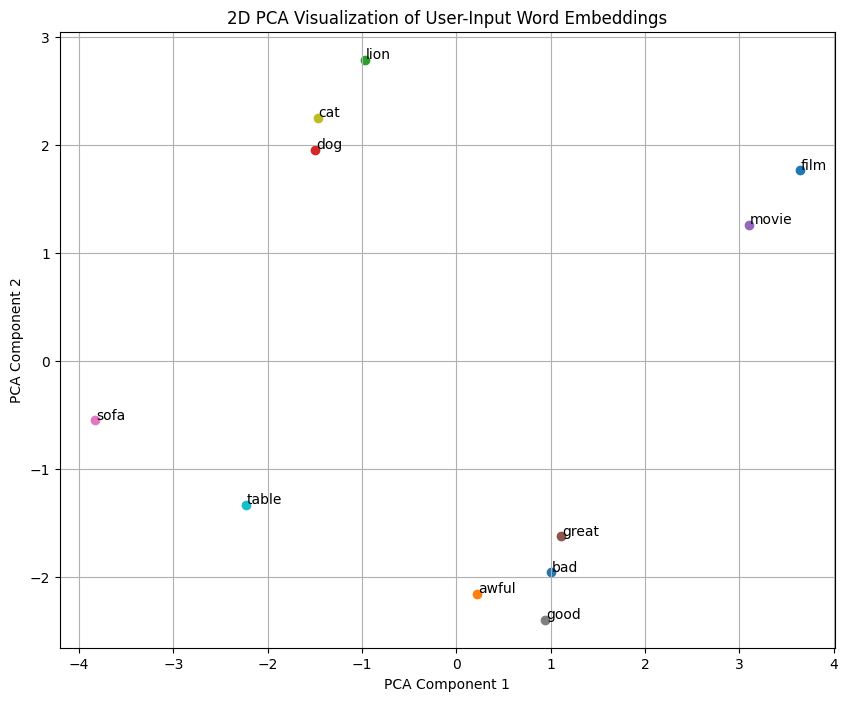

In [ ]:
# visualization requirement
# create 2D scatter plot to visually show how similar and dissimilar words cluster together in embedding space
# using user input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# from word_pairs
unique_words = set()

for w1, w2 in word_pairs:
    unique_words.add(w1)
    unique_words.add(w2)

unique_words = list(unique_words)

# extracting embeddings with OOV handling
vectors = []
labels = []

for w in unique_words:
    vec, msg = get_embedding_with_oov_handling(w, glove)

    # only visualize words that successfully produced embedding
    if vec is not None:
        vectors.append(vec)
        labels.append(w)
    else:
        print(f"Skipping '{w}': {msg}")

# convert list of vectors to numpy array
vectors = np.array(vectors)

# reduce to 2D using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# plot
plt.figure(figsize=(10, 8))

for i, word in enumerate(labels):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0] + 0.01, reduced[i, 1] + 0.01, word)

plt.title("2D PCA Visualization of User-Input Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

The 2D scatter plot shows how similar and dissimilar words cluster together in the embedding space using the words where the user can input pairs for simultaneous
similarity computation. Word embeddings are high dimensional vectors which cannot directly be visualized. PCA reduces 100 dimensions to 2 dimensions which allows projecting the embeddings into a lower space while maintaining the geometric structure. The words closer together are more semantically similar. The movie-film clusters in the top right showing a strong synonym relationship and PCA visually confirms a high similarity, expected for near synonyms. The animal cluster is in the top left. Cat and dog are very close where lion is separated but still near. The separation makes sense because a lion is in wildlife context where cat/dog are in domestic contexts. The embedding space shows the contextual similarity with the biological taxonomy. The sentiment cluster of good, great, bad, and awful are grouped together in the bottom right. Embeddings capture context similarity, which is why good and bad are close. positive and negative adjectives can appear in similar sentence structures. The furniture pair of table-sofa are left and separated, somewhat close to each other but separated from animals and movies. They share category level similarity both being furniture but not as strong as cat-dog.

Part 3: Designing a Novel Dissimilarity Metric

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# define custom dissimilarity score that goes beyond cosine similarity
# euclidean distance
# angular distance - novel metric derived from cosine similarity

'''
Compute euclidean distance between two embedding vectors

Parameters:
  vec1: first embedding vector
  vec2: second embedding vector

Returns:
  euclidean distance if both vectors exist
  else None if either vector missing
'''
def euclidean_distance(vec1, vec2):
    # if missing vector distance cannot be computed
    if vec1 is None or vec2 is None:
        return None

    # compute L2 (euclidean) distance
    return np.linalg.norm(vec1 - vec2)

'''
Compute angular distance between two embedding vectors

Parameters:
  vec1: first embedding vector
  vec2: second embedding vector
  eps: constant to avoid numerical instability

Returns:
  angular distance in [0,1] if vectors exist
  else None if either vector missing
'''
def angular_distance(vec1, vec2, eps=1e-8):
    # compute cosine similarity
    cos_sim = cosine_similarity(vec1, vec2, eps)

    # missing vectors return None
    if cos_sim is None:
        return None

    # clip cosine similairty to valid range to avoid arccos errors
    cos_sim = np.clip(cos_sim, -1.0, 1.0)

    # convert cosine similarity to normalized angular distance
    return np.arccos(cos_sim) / np.pi

For the custom dissimilarity score that goes beyond cosine similarity I implemented Euclidean distance and angular distance. Euclidean distance measures the straight-line distance between two word vectors in the embedding space. Cosine similarity only considers direction where Euclidean distance takes both magnitude and direction into account. This makes it sensitive to the overall position of vectors in space and can show absolute differences between embeddings.

**Explain why metric captures novelty/diversity better than cosine similarity alone** \
Cosine similarity measures the directional alignment between two word vectors and returns a value between −1 and 1. It captures whether two vectors point in similar directions, but it compresses differences when similarity values are high. Moderately similar word pairs may appear closer than they actually are in semantic space.

Angular distance is derived from cosine similarity.

Angular distance = arccos(cosine_similarity) / π

Instead of measuring alignment directly, angular distance converts cosine similarity into a normalized geometric distance in angular space. While cosine similarity focuses on directional agreement, angular distance interprets that agreement as an angle between vectors. This transformation expands differences between moderately similar words and makes semantic contrast more pronounced.

Therefore, angular distance captures novelty and diversity better than cosine similarity alone because it emphasizes geometric separation rather than raw directional similarity. This makes it more sensitive when comparing semantically diverse word pairs.

Citations: https://www.jair.org/index.php/jair/article/view/10640

In [ ]:
# allow users to toggle between different similarity/dissimilarity measures via function parameters

'''
Compute a similarity or disimilarity metric between two words

Parameters:
  word1: first input word
  word2: second input word
  model: pre-trained embedding model
  metric: metric to compute

Returns:
  computed metric value else None
'''
def compute_metric(word1, word2, model, metric="cosine"):
    # retrieve embeddings and oov message for both words
    v1, msg1 = get_embedding_with_oov_handling(word1, model)
    v2, msg2 = get_embedding_with_oov_handling(word2, model)

    # select and compute metric
    if metric == "cosine":
        return cosine_similarity(v1, v2)
    elif metric == "euclidean":
        return euclidean_distance(v1, v2)
    elif metric == "angular":
        return angular_distance(v1, v2)

 The function compute_metric allows computation of differnt similarity or dissimilairy measures between two input words by selecting a metric through a parameter. It first retrieves embeddings with OOV handling which ensures that the vector is retrieved from the pre-trained model if it exists and if a word os OOV the function handles it correctly. It then selects the metric dynamically to choose which similarity or dissimilairty to compute

Enter a metric to plot (cosine, euclidean, angular): euclidean



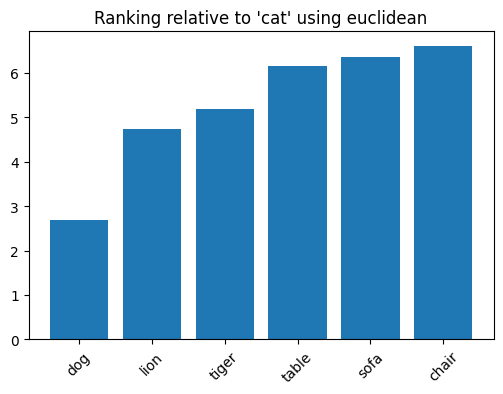


All three plots for demonstration purposes:



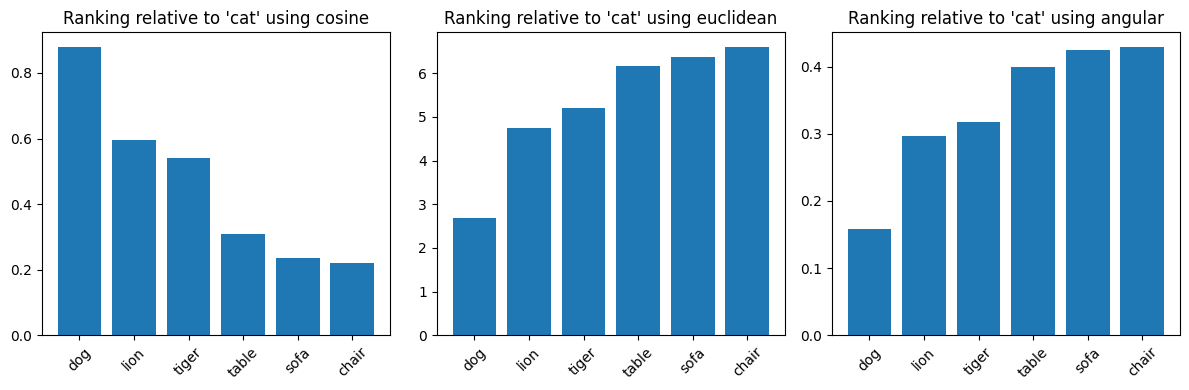

In [ ]:
# visualization requirement 1
# plot ranking of words based on similarity/dissimilarity to a given word

'''
Rank list of candidate words by similarity or dismiliarity to an anchor word

Parameters:
  anchor_word: reference word to compare against
  candidate_words: words to be ranked relative to anchor
  model: pre-trained embedding model
  metric: metric to use

Returns:
  list of tuples:
      sorted list of (word, score) pairs
        cosine similarity: higher score = more similar
        distances: lower score = more similar
'''
def rank_words(anchor_word, candidate_words, model, metric="cosine"):
    scores = [] # stores pairs
    for w in candidate_words:
        # compute selected metric between anchor word and candidate word
        score = compute_metric(anchor_word, w, model, metric=metric)
        scores.append((w, score))

    # sort candidates by similarity/distance
    if metric == "cosine":
        # higher cosine similarity = more similar
        scores.sort(key=lambda x: x[1], reverse=True)
    else:
        # lower distance = more similar
        scores.sort(key=lambda x: x[1])

    return scores

# example run of ranking plot
anchor = "cat"
candidates = ["dog", "lion", "table", "chair", "sofa", "tiger"]

metrics = ["cosine", "euclidean", "angular"]

# allow users to toggle between differnt similarity/disimilairity measures via function parameters
user_input = input("Enter a metric to plot (cosine, euclidean, angular): ").strip().lower()
print()
if user_input in ["cosine", "euclidean", "angular"]:
    # rank and plot selected metric
    ranked = rank_words(anchor, candidates, glove, metric=user_input)
    words = [w for w, s in ranked]
    scores = [s for w, s in ranked]

    plt.figure(figsize=(6, 4))
    plt.bar(words, scores)
    plt.title(f"Ranking relative to '{anchor}' using {user_input}")
    plt.xticks(rotation=45)
    plt.show()

# wide figure with 3 subplots - one per metric
plt.figure(figsize=(12, 4))

print()
print("All three plots for demonstration purposes:")
print()

for i, metric in enumerate(metrics):
    # rank words according to selected metric
    ranked = rank_words(anchor, candidates, glove, metric=metric)

    # seperate words and scores for plotting
    words = [word for (word, score) in ranked]
    scores = [score for (word, score) in ranked]

    # subplots for each metric
    plt.subplot(1, 3, i+1)
    plt.bar(words, scores) # shows ranking scores
    plt.title(f"Ranking relative to '{anchor}' using {metric}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The code above allows users to toggle between different measures. The rank_words function computes similarity/distance metric for each word with a score relative to the anchor word using the model and the inputted metric. It sorts the words by similarity/distance where a higher score for cosine similarity indicate closer similarity and a lower score for distance metrics indicate closer similarity. It allows users to toggle between different measures and a bar chart is displayed for the user-selected metric. I also loop through all three metrics and display the charts for demonstration purposes for the assignment, so all three metrics can be seen. It shows the differences between similarity and distance metrics all together. \
The example run shows the anchor word cat and candidate words used before. The user enters the desired metric and a single bar chart is shown to which word is most similar to cat based on cosine similarity. It shows the how  "cat" rank against "dog," "lion," and "table" using different
metrics. \
The output chart with all three bar graphs shows how the ranking changes depending on the metric chosen. The cosine similarity plot shows that dog is most similar to cat, then lion then tiger. The furniture words are least similar. Cosine similarity measures directional similarity in embedding space, not magnitude. It shows the higher value, the more similar and is sorted in descending order The Euclidean distance plot has lower value means more similar and is sorted in ascending order. Dog has the smallest distance, so it is closest to cat, then lion, then tiger, and again furniture words are farther. Euclidean distance measures the absolute geometric distance between vectors, and although the scale looks different from cosine, their relative ranking is similar. The angular distance plot has a lower value meaning more similar and is also sorted ascending. The order again goes dog, lion, tiger and furniture farthest. The angular distance is close to cosine because it is derived from it, so it produces a similar ranking.

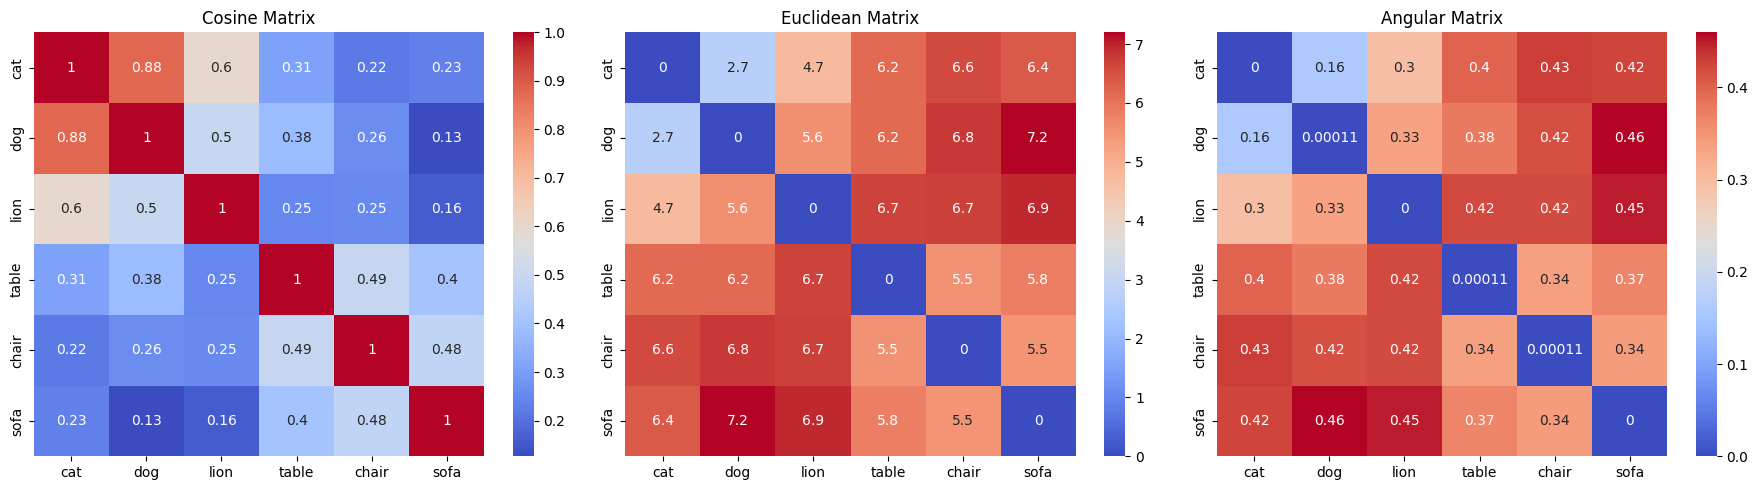

In [ ]:
# visualization requirement 2
# heatmap to demonstrate and compare similairity and sisimilarity across multiple word pairs

# words to include in heatmap comparision
heatmap_words = ["cat", "dog", "lion", "table", "chair", "sofa"]

'''
Compute a square similarity/distance matrix for a list of words

Parameters:
  words: words to compare pairwise
  model: pre-trained embedding model
  metric: metric to use

Returns:
   (n x n) matrix of similarity/distance values
'''
def compute_matrix(words, model, metric="cosine"):
    n = len(words)
    mat = np.zeros((n, n)) # empty matrix initilization

    # each cell (i, j) contains metric value between words[i] and words[j]
    for i in range(n):
        for j in range(n):
            # compute metric between each pair of words
            mat[i, j] = compute_metric(words[i], words[j], model, metric=metric)
    return mat

# heatmaps for different metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    # compute pairwise matrix for selectic metric
    mat = compute_matrix(heatmap_words, glove, metric=metric)

    # heatmap plot for metric
    sns.heatmap(mat, xticklabels=heatmap_words, yticklabels=heatmap_words,
                cmap="coolwarm", annot=True, ax=ax)
    ax.set_title(f"{metric.capitalize()} Matrix")

plt.tight_layout()
plt.show()

The second visualization code computes pairwise similarity/distance. Each cell (i, j) stores the similarity/distance between the word i and word j. There is three different heatmaps for each of the measures. The cosine matrix shows every word is similar to itself. The animal cluster cat-dog is 0.88, cat-lion is 0.6 and dog-lion is 0.5 which shows the animals are strongly similar to each other. The furniture clusters show the furniture words are also grouped and there is much lower similarity between animals and furniture, showing semantic clustering in embedding space. The Euclidean matrix shows animals are geometrically closer to animals, furniture closer to furniture and cross-category words are further apart. This shows the same clustering as cosine but in a geometric space. The angular matrix also shows the same similarities and differences, and behaves very similarly to cosine because of its derivation. The heatmaps are able to show that word embeddings capture semantic relationships and similar concepts cluster together in vector space.